Étude d’un processus AR(2)

1 – Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


2 – Définition et simulation du processus

In [2]:
np.random.seed(0)

# Paramètres
n = 500
phi1 = -0.3
phi2 = 0.4
sigma = 1

# Bruit blanc
eps = np.random.normal(0, sigma, n)

# Initialisation
y = np.zeros(n)

# Simulation du AR(2)
for t in range(2, n):
    y[t] = phi1 * y[t-1] + phi2 * y[t-2] + eps[t]


3 – Plot simple de la série

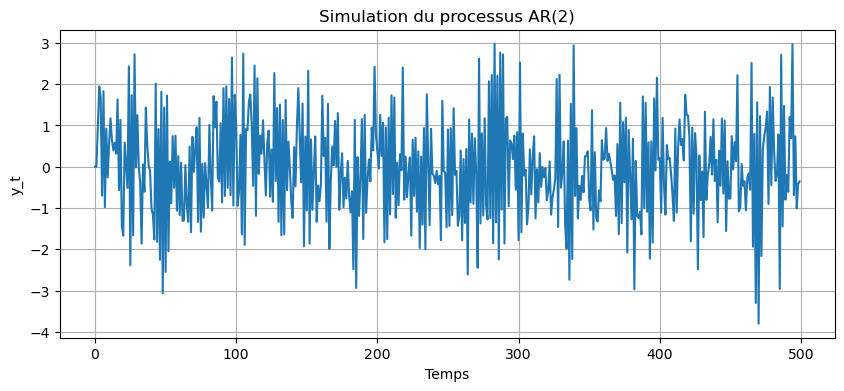

In [3]:
plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Simulation du processus AR(2)")
plt.xlabel("Temps")
plt.ylabel("y_t")
plt.grid()
plt.show()


4 – Corrélogramme (ACF)

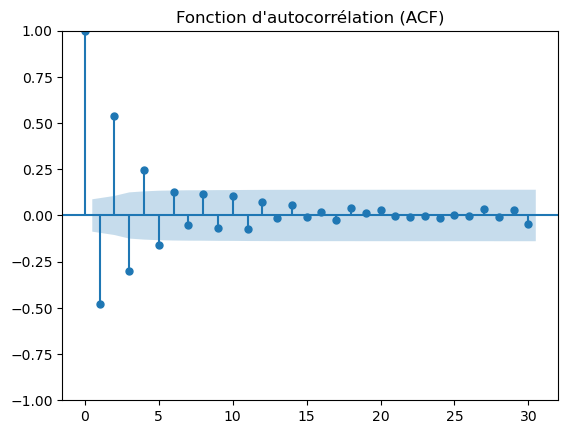

In [4]:
plot_acf(y, lags=30)
plt.title("Fonction d'autocorrélation (ACF)")
plt.show()


5 – Corrélogramme (PACF)

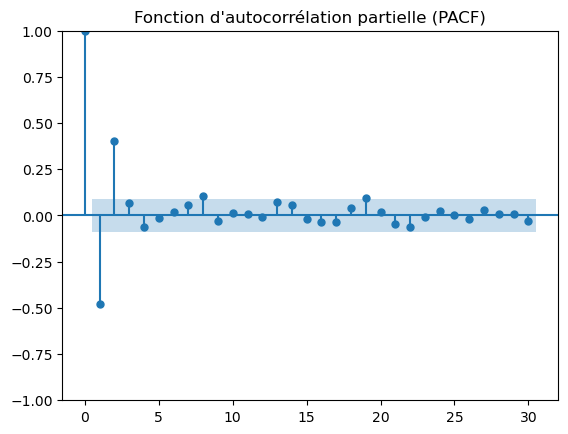

In [5]:
plot_pacf(y, lags=30, method="ywm")
plt.title("Fonction d'autocorrélation partielle (PACF)")
plt.show()


6 – Estimation du modèle AR(2)

In [6]:
model = sm.tsa.ARIMA(y, order=(2,0,0))
result = model.fit()

print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -707.072
Date:                Mon, 02 Feb 2026   AIC                           1422.145
Time:                        09:29:47   BIC                           1439.003
Sample:                             0   HQIC                          1428.760
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0329      0.050     -0.655      0.512      -0.131       0.066
ar.L1         -0.2857      0.042     -6.801      0.000      -0.368      -0.203
ar.L2          0.3990      0.041      9.629      0.0

7 – Test d’autocorrélation (Q-stat / Ljung–Box)

In [7]:
lb_test = acorr_ljungbox(result.resid, lags=[10, 20], return_df=True)
lb_test


,lb_stat,lb_pvalue
10,12.523705,0.251534
20,22.596080,0.309060


8 – Vérification de la stationnarité

In [8]:
coeffs = [1, -phi1, -phi2]
roots = np.roots(coeffs)

print("Racines :", roots)
print("Modules :", np.abs(roots))


Racines : [-0.8  0.5]
Modules : [0.8 0.5]


9 – Conclusion automatique

In [9]:
if np.all(np.abs(roots) > 1):
    print("Le processus AR(2) est stationnaire.")
else:
    print("Le processus AR(2) n'est pas stationnaire.")

print("Le processus est inversible (ARMA(2,0)).")


Le processus AR(2) n'est pas stationnaire.
Le processus est inversible (ARMA(2,0)).
